In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import AdaBoostClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

import xgboost as xgb
import time
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print(xgb.__version__)

3.3.0


In [41]:
df = pd.read_csv('wine.csv')
df.info()
df["quality"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.0+ KB


array(['bad', 'good'], dtype=object)

In [42]:
label_encoder = LabelEncoder()
df["quality"] = label_encoder.fit_transform(df["quality"])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [43]:
X = pd.get_dummies(df.drop("quality", axis=1), drop_first=True)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y )


print(f'Eğitim seti: {X_train.shape[0]} örnek')
print(f'Test seti  : {X_test.shape[0]} örnek')
X.head()

Eğitim seti: 1279 örnek
Test seti  : 320 örnek


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


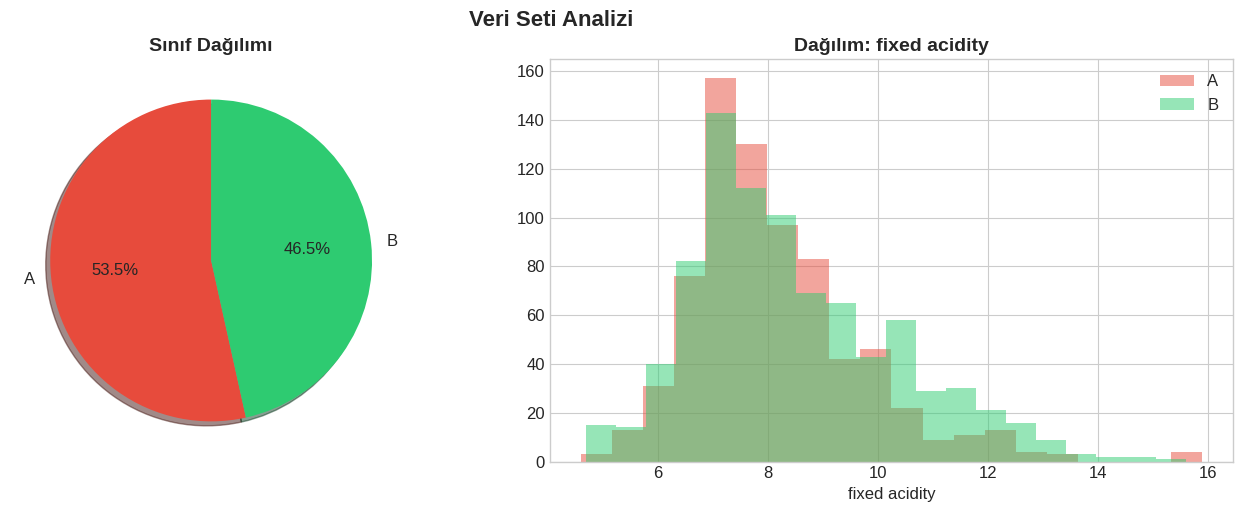

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = y.value_counts()
labels = ['A', 'B']
colors = ['#e74b3c', '#2ecb71']
axes[0].pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12}
)
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')





features_to_plot = df.columns[:5]
for i, feat in enumerate(features_to_plot):
    axes[1].hist(X[feat][y==0], alpha=0.5, label='A', color='#e74c3c', bins=20)
    axes[1].hist(X[feat][y==1], alpha=0.5, label='B',    color='#2ecc71', bins=20)
    break  # Döngüyü ilk özellikte durdur; sadece 1 özellik yeterli
axes[1].set_title(f'Dağılım: {features_to_plot[0]}', fontsize=14, fontweight='bold')
axes[1].set_xlabel(features_to_plot[0])
axes[1].legend()

plt.tight_layout()
plt.suptitle('Veri Seti Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [45]:
#ADABOOST
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)

start = time.time()
ada_model.fit(X_train, y_train)
ada_time = time.time() - start

ada_pred = ada_model.predict(X_test)
ada_prob = ada_model.predict_proba(X_test)[:, 1]
ada_acc  = accuracy_score(y_test, ada_pred)
ada_auc = roc_auc_score(y_test, ada_prob)
ada_f1 = f1_score(y_test, ada_pred)
ada_precision = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)

print(f'✅ Eğitim Süresi   : {ada_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {ada_acc:.4f}  ({ada_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {ada_auc:.4f}')
print(f'📊 F1 Skoru        : {ada_f1:.4f}')
print(f'📊 Precision       : {ada_precision:.4f}')
print(f'📊 Recall          : {ada_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, ada_pred, target_names=['A', 'B']))

✅ Eğitim Süresi   : 0.3059 sn
📊 Doğruluk (Acc)  : 0.7500  (75.00%)
📊 AUC-ROC         : 0.8263
📊 F1 Skoru        : 0.7674
📊 Precision       : 0.7630
📊 Recall          : 0.7719

📋 Detaylı Rapor:
              precision    recall  f1-score   support

           A       0.73      0.72      0.73       149
           B       0.76      0.77      0.77       171

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320



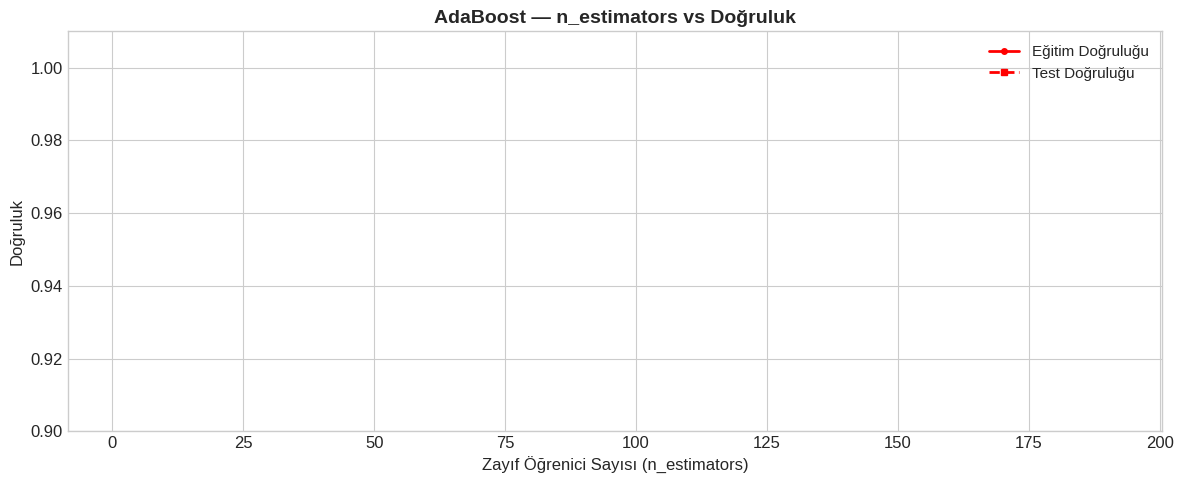

In [46]:
n_estimators_range = range(1, 201, 10)
ada_train_scores = []
ada_test_scores  = []

for n in n_estimators_range:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        learning_rate=0.1,
        algorithm='SAMME',
        random_state=42
    )
    m.fit(X_train, y_train)
    ada_train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    ada_test_scores.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(12, 5))
plt.plot(n_estimators_range, ada_train_scores, 'r-o', markersize=4,
         label='Eğitim Doğruluğu', linewidth=2)
plt.plot(n_estimators_range, ada_test_scores, 'r--s', markersize=4,
         label='Test Doğruluğu', linewidth=2)
plt.xlabel('Zayıf Öğrenici Sayısı (n_estimators)', fontsize=12)
plt.ylabel('Doğruluk', fontsize=12)
plt.title('AdaBoost — n_estimators vs Doğruluk', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0.90, 1.01)
plt.tight_layout()
plt.show()

In [47]:
#XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

start = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
xgb_time = time.time() - start
xgb_pred = xgb_model.predict(X_test)


xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_acc    = accuracy_score(y_test, xgb_pred)
xgb_auc    = roc_auc_score(y_test, xgb_prob)
xgb_f1     = f1_score(y_test, xgb_pred)
xgb_prec   = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)

print(f'✅ Eğitim Süresi   : {xgb_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {xgb_auc:.4f}')
print(f'📊 F1 Skoru        : {xgb_f1:.4f}')
print(f'📊 Precision       : {xgb_prec:.4f}')
print(f'📊 Recall          : {xgb_recall:.4f}')
print()
print('📋 Detaylı Rapor:')
print(classification_report(y_test, xgb_pred, target_names=['A', 'B']))

✅ Eğitim Süresi   : 0.0909 sn
📊 Doğruluk (Acc)  : 0.7688  (76.88%)
📊 AUC-ROC         : 0.8636
📊 F1 Skoru        : 0.7758
📊 Precision       : 0.8050
📊 Recall          : 0.7485

📋 Detaylı Rapor:
              precision    recall  f1-score   support

           A       0.73      0.79      0.76       149
           B       0.81      0.75      0.78       171

    accuracy                           0.77       320
   macro avg       0.77      0.77      0.77       320
weighted avg       0.77      0.77      0.77       320



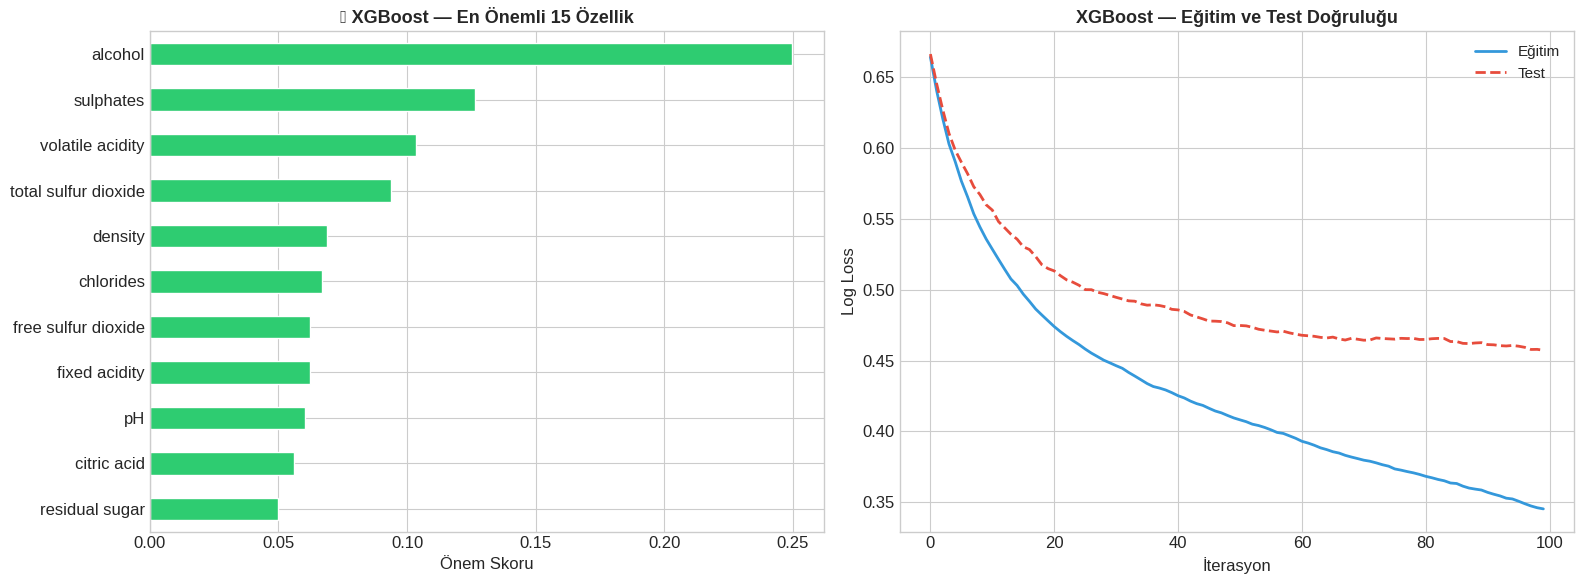

In [54]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

feat_importance.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('🟢 XGBoost — En Önemli 15 Özellik', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Önem Skoru')

results = xgb_model.evals_result()
axes[1].plot(results['validation_0']['logloss'],
             label='Eğitim', color='#3498db', linewidth=2)
axes[1].plot(results['validation_1']['logloss'],
             label='Test', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('XGBoost — Eğitim ve Test Doğruluğu', fontsize=13, fontweight='bold')
axes[1].set_xlabel('İterasyon')
axes[1].set_ylabel('Log Loss')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

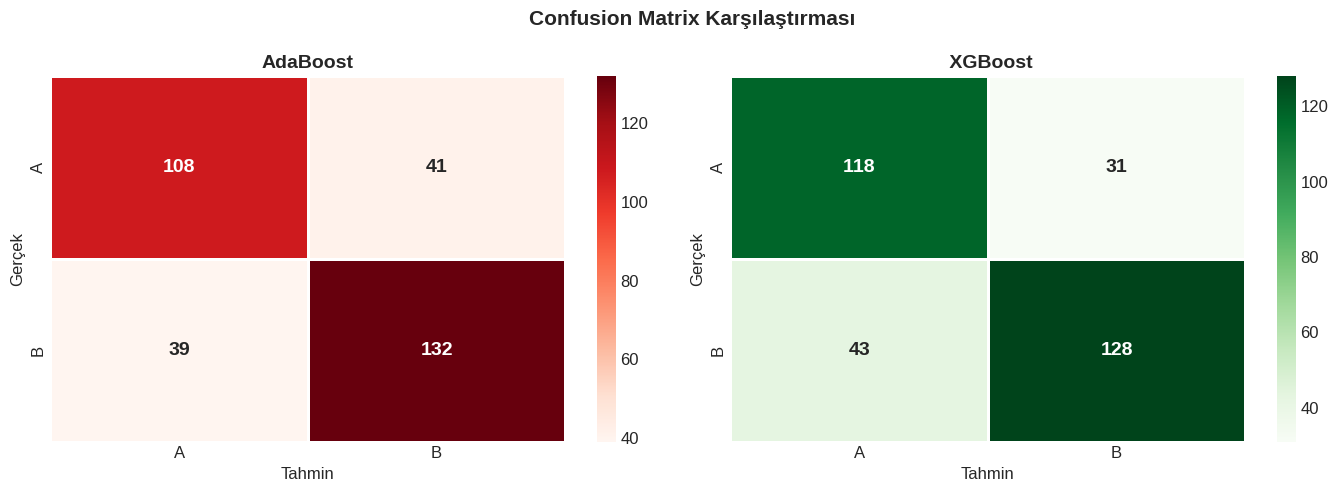

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title, color in zip(
    axes,
    [ada_pred, xgb_pred],
    ['AdaBoost', ' XGBoost'],
    ['Reds', 'Greens']
):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,             # Hücrelere sayıları yaz
        fmt='d',                # Tam sayı formatı (float değil)
        cmap=color,             # Renk haritası
        ax=ax,
        xticklabels=['A', 'B'],
        yticklabels=['A', 'B'],
        linewidths=2,
        linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Tahmin', fontsize=12)
    ax.set_ylabel('Gerçek', fontsize=12)

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

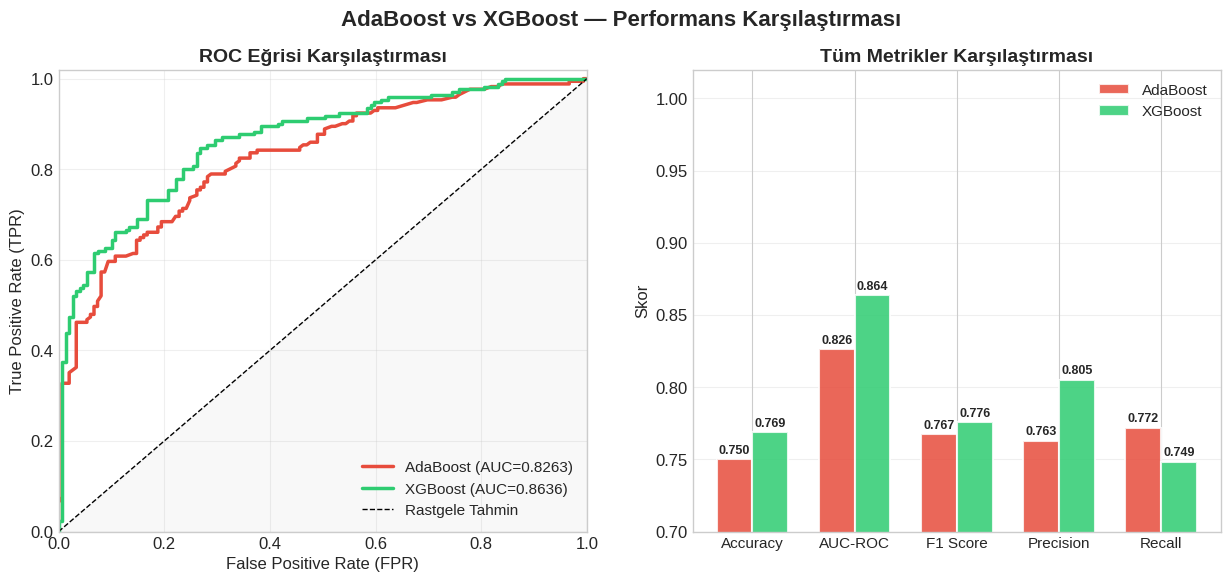

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for prob, label, color, acc, auc in [
    (ada_prob, 'AdaBoost', '#e74c3c', ada_acc, ada_auc),
    (xgb_prob, 'XGBoost',  '#2ecc71', xgb_acc, xgb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{label} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)


metrics    = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
ada_scores = [ada_acc, ada_auc, ada_f1, ada_precision, ada_recall]
xgb_scores = [xgb_acc, xgb_auc, xgb_f1, xgb_prec, xgb_recall]

x = np.arange(len(metrics))
width = 0.35


bars1 = axes[1].bar(x - width/2, ada_scores, width, label='AdaBoost',
                     color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = axes[1].bar(x + width/2, xgb_scores, width, label='XGBoost',
                     color='#2ecc71', alpha=0.85, edgecolor='white', linewidth=1.5)


for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Skor', fontsize=12)
axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_ylim(0.70, 1.02)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('AdaBoost vs XGBoost — Performans Karşılaştırması',
             fontsize=16, fontweight='bold')
plt.show()

 AdaBoost  CV Scores: [0.7125 0.7125 0.7781 0.7312 0.7335]
   Ortalama: 0.7336 ± 0.0240

XGBoost   CV Scores: [0.7125 0.6812 0.7688 0.7469 0.7429]
   Ortalama: 0.7305 ± 0.0304


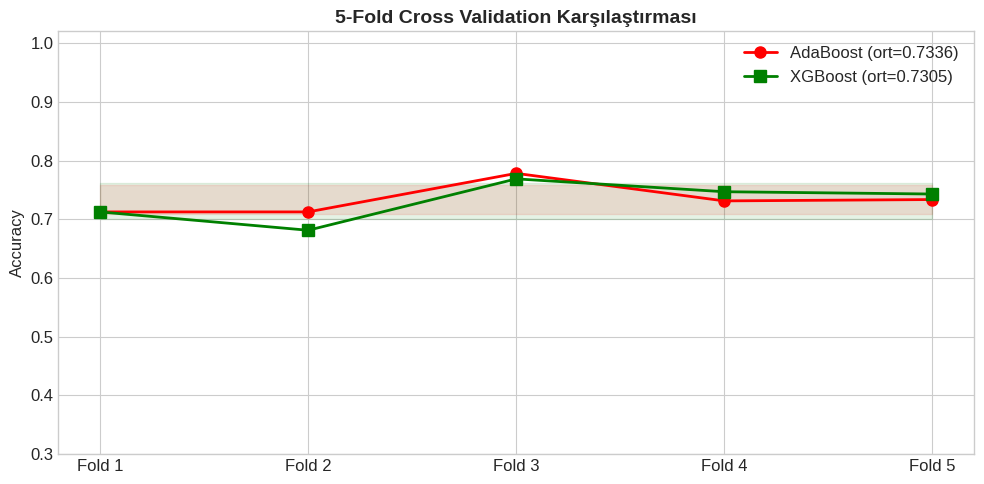

In [68]:
#Cross Validation

ada_cv = cross_val_score(ada_model, X, y, cv=5, scoring='accuracy')
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print(f' AdaBoost  CV Scores: {ada_cv.round(4)}')
print(f'   Ortalama: {ada_cv.mean():.4f} ± {ada_cv.std():.4f}')
print()
print(f'XGBoost   CV Scores: {xgb_cv.round(4)}')
print(f'   Ortalama: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)

ax.plot(x, ada_cv, 'r-o', markersize=8, linewidth=2,
        label=f'AdaBoost (ort={ada_cv.mean():.4f})')
ax.plot(x, xgb_cv, 'g-s', markersize=8, linewidth=2,
        label=f'XGBoost (ort={xgb_cv.mean():.4f})')

ax.fill_between(x,
                ada_cv.mean() - ada_cv.std(),
                ada_cv.mean() + ada_cv.std(),
                alpha=0.1, color='red')
ax.fill_between(x,
                xgb_cv.mean() - xgb_cv.std(),
                xgb_cv.mean() + xgb_cv.std(),
                alpha=0.1, color='green')

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Cross Validation Karşılaştırması', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0.30, 1.02)
plt.tight_layout()
plt.show()

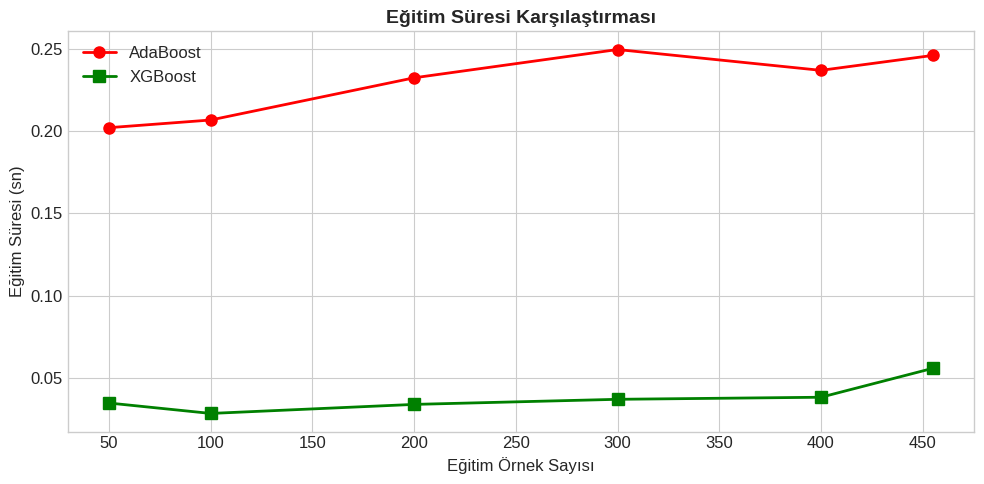


Full dataset eğitim süreleri:
  AdaBoost : 0.3059 sn
  XGBoost  : 0.0909 sn


In [70]:
sizes = [50, 100, 200, 300, 400, 455]
ada_times_list = []
xgb_times_list = []

for s in sizes:
    Xs = X_train.iloc[:s]
    ys = y_train.iloc[:s]

    m1 = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=0.1, algorithm='SAMME', random_state=42
    )
    t1 = time.time()
    m1.fit(Xs, ys)
    ada_times_list.append(time.time() - t1)
    m2 = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    t2 = time.time()
    m2.fit(Xs, ys)
    xgb_times_list.append(time.time() - t2)
plt.figure(figsize=(10, 5))
plt.plot(sizes, ada_times_list, 'r-o', markersize=8, linewidth=2, label='AdaBoost')
plt.plot(sizes, xgb_times_list, 'g-s', markersize=8, linewidth=2, label='XGBoost')

plt.xlabel('Eğitim Örnek Sayısı', fontsize=12)
plt.ylabel('Eğitim Süresi (sn)', fontsize=12)
plt.title('Eğitim Süresi Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
print(f'\nFull dataset eğitim süreleri:')
print(f'  AdaBoost : {ada_time:.4f} sn')
print(f'  XGBoost  : {xgb_time:.4f} sn')

In [76]:
# ─── Tüm metrikleri tek tabloda özetle ──────────────────────────────────────
results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall',
               'CV Ortalama', 'CV Std', 'Eğitim Süresi (sn)'],
    'AdaBoost ': [
        f'{ada_acc:.4f}', f'{ada_auc:.4f}', f'{ada_f1:.4f}',
        f'{ada_precision:.4f}', f'{ada_recall:.4f}',
        f'{ada_cv.mean():.4f}', f'{ada_cv.std():.4f}',
        f'{ada_time:.4f}'
    ],
    'XGBoost ': [
        f'{xgb_acc:.4f}', f'{xgb_auc:.4f}', f'{xgb_f1:.4f}',
        f'{xgb_prec:.4f}', f'{xgb_recall:.4f}',
        f'{xgb_cv.mean():.4f}', f'{xgb_cv.std():.4f}',
        f'{xgb_time:.4f}'
    ],
    'Kazanan': [
        # Her metrik için iki modeli karşılaştır ve kazananı belirle
        ' XGBoost' if xgb_acc    >= ada_acc    else ' AdaBoost',
        ' XGBoost' if xgb_auc    >= ada_auc    else ' AdaBoost',
        ' XGBoost' if xgb_f1     >= ada_f1     else ' AdaBoost',
        ' XGBoost' if xgb_prec   >= ada_precision   else ' AdaBoost',
        ' XGBoost' if xgb_recall >= ada_recall else ' AdaBoost',
        ' XGBoost' if xgb_cv.mean() >= ada_cv.mean() else ' AdaBoost',
        ' XGBoost' if xgb_cv.std()  <= ada_cv.std()  else ' AdaBoost',
        # Süre için: daha kısa süre kazanır
        ' XGBoost' if xgb_time <= ada_time else ' AdaBoost'
    ]
})

print('\n' + '='*65)
print('         📊 ADABOOST vs XGBOOST — SONUÇ TABLOSU')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

# Kazanılan kategori sayısını say
xgb_wins = sum(1 for k in results_df['Kazanan'] if 'XGBoost' in k)
ada_wins = sum(1 for k in results_df['Kazanan'] if 'AdaBoost' in k)
print(f'\n🏆 GENEL SONUÇ:')
print(f'    XGBoost kazandı  : {xgb_wins}/{len(results_df)} kategoride')
print(f'    AdaBoost kazandı : {ada_wins}/{len(results_df)} kategoride')


         📊 ADABOOST vs XGBOOST — SONUÇ TABLOSU
            Metrik AdaBoost  XGBoost    Kazanan
          Accuracy    0.7500   0.7688   XGBoost
           AUC-ROC    0.8263   0.8636   XGBoost
          F1 Score    0.7674   0.7758   XGBoost
         Precision    0.7630   0.8050   XGBoost
            Recall    0.7719   0.7485  AdaBoost
       CV Ortalama    0.7336   0.7305  AdaBoost
            CV Std    0.0240   0.0304  AdaBoost
Eğitim Süresi (sn)    0.3059   0.0909   XGBoost

🏆 GENEL SONUÇ:
    XGBoost kazandı  : 5/8 kategoride
    AdaBoost kazandı : 3/8 kategoride
